In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

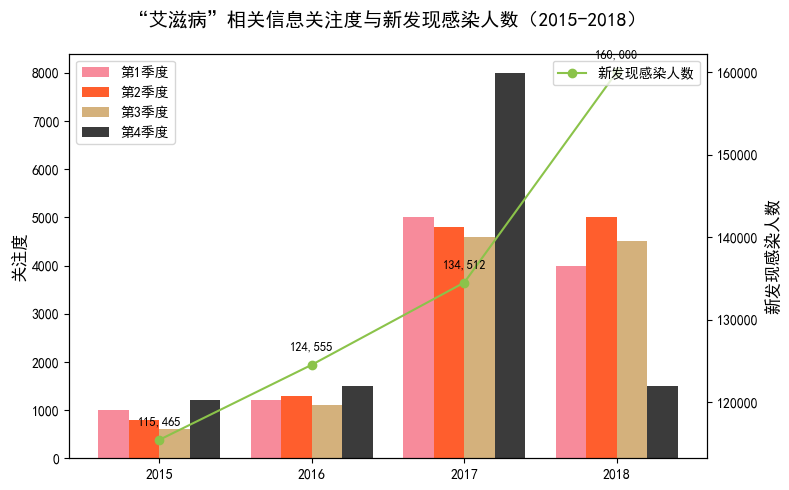

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
years = [2015, 2016, 2017, 2018]
# 各季度关注度（第1-4季度）
q1 = [1000, 1200, 5000, 4000]  
q2 = [800, 1300, 4800, 5000]
q3 = [600, 1100, 4600, 4500]
q4 = [1200, 1500, 8000, 1500]
# 新发现感染人数
new_infections = [115465, 124555, 134512, 160000]  

# 用于在同一X轴上绘制多组柱状图的偏移量
x = np.arange(len(years))  
width = 0.2  

# 创建画布和子图
fig, ax1 = plt.subplots(figsize=(8, 5))

# 绘制各季度关注度的柱状图
ax1.bar(x - 1.5*width, q1, width, label='第1季度', color='#f78b9b')
ax1.bar(x - 0.5*width, q2, width, label='第2季度', color='#ff5e2d')
ax1.bar(x + 0.5*width, q3, width, label='第3季度', color='#d4b17c')
ax1.bar(x + 1.5*width, q4, width, label='第4季度', color='#3b3b3b')

# 设置左侧Y轴（关注度）的标题
ax1.set_ylabel('关注度', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.legend(loc='upper left')

# 创建右侧Y轴，用于绘制新发现感染人数的折线图
ax2 = ax1.twinx()
line, = ax2.plot(x, new_infections, marker='o', color='#8bc34a', label='新发现感染人数')

# 添加折线数据标注
for i, (x_val, y_val) in enumerate(zip(x, new_infections)):
    # 将感染人数转换为带千位分隔符的字符串
    y_text = f"{y_val:,}"
    ax2.annotate(y_text,  # 标注文本
                 (x_val, y_val),  # 数据点位置
                 textcoords="offset points",  # 文本坐标相对于数据点的偏移
                 xytext=(0,10),  # X和Y方向的偏移量
                 ha='center',  # 水平对齐方式
                 fontsize=9)  # 字体大小

ax2.set_ylabel('新发现感染人数', fontsize=12)
ax2.legend(loc='upper right')

# 图表标题
plt.title('“艾滋病”相关信息关注度与新发现感染人数（2015-2018）', fontsize=14, pad=20)

# 调整布局
plt.tight_layout()
# 显示图表
plt.show()

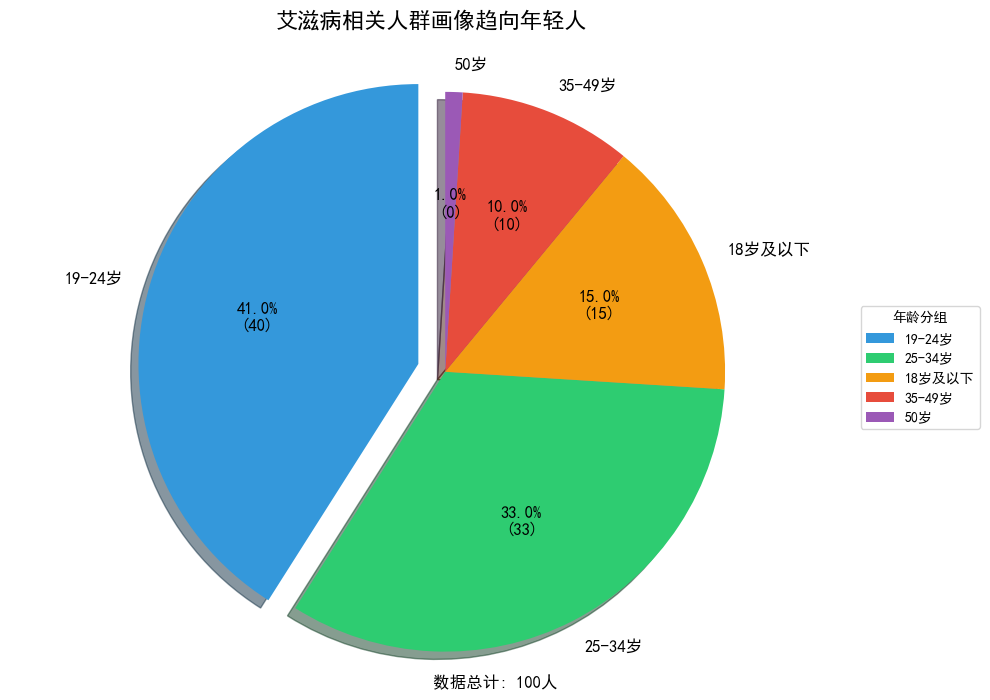

In [7]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 数据
labels = ['19-24岁', '25-34岁', '18岁及以下', '35-49岁', '50岁']
sizes = [41, 33, 15, 10, 1]
# 自定义颜色，使用更专业的配色方案
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
# 突出显示最大的扇形
explode = (0.1, 0, 0, 0, 0)  

# 创建画布和子图
fig, ax = plt.subplots(figsize=(10, 7))

# 绘制饼图，添加阴影和自定义百分比样式
wedges, texts, autotexts = ax.pie(
    sizes, 
    explode=explode,
    labels=labels,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(sizes)/100)})',  # 同时显示百分比和实际人数
    shadow=True,
    startangle=90,
    textprops={'fontsize': 12}
)

# 设置标题
ax.set_title('艾滋病相关人群画像趋向年轻人', fontsize=16, pad=20)

# 使饼图为正圆形
ax.axis('equal')  

# 添加图例
plt.legend(wedges, labels, title="年龄分组", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# 添加注释
plt.figtext(0.5, 0.01, f"数据总计: {sum(sizes)}人", ha="center", fontsize=12)

# 调整布局
plt.tight_layout()

# 显示图形
plt.show()    

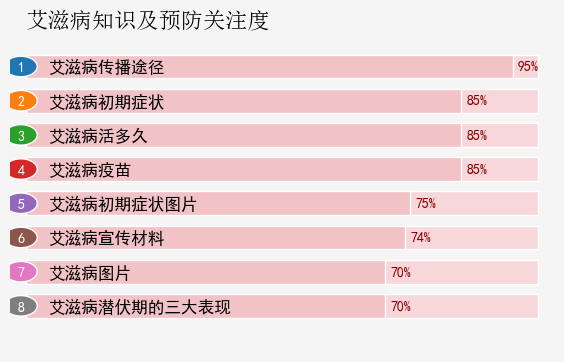

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 标题与内容列表
title = "艾滋病知识及预防关注度"
items = [
    "艾滋病传播途径",
    "艾滋病初期症状",
    "艾滋病活多久",
    "艾滋病疫苗",
    "艾滋病初期症状图片",
    "艾滋病宣传材料",
    "艾滋病图片",
    "艾滋病潜伏期的三大表现"
]
# 根据原图红色长条长度比例设置进度值
progress = np.array([0.95, 0.85, 0.85, 0.85, 0.75, 0.74, 0.70, 0.70])  

# 创建画布与轴
fig, ax = plt.subplots(figsize=(6, 4), facecolor="#F5F5F5")
# 隐藏坐标轴
ax.axis("off")  

# 绘制标题
plt.text(
    0.03, 0.95, title, 
    fontsize=16, fontweight="bold", fontfamily="SimSun"
)

# 逐个绘制条目
for i, (text, p) in enumerate(zip(items, progress), start=1):
    # 绘制进度条背景
    rect_bg = plt.Rectangle(
        (0.03, 0.9 - 0.1 * i), 0.94, 0.07, 
        facecolor="#F8D7DA", edgecolor="white"
    )
    ax.add_patch(rect_bg)
    # 绘制进度条填充（使用不同的进度值）
    rect_fill = plt.Rectangle(
        (0.03, 0.9 - 0.1 * i), 0.94 * p, 0.07, 
        facecolor="#F1C2C6", edgecolor="white"
    )
    ax.add_patch(rect_fill)
    # 绘制进度百分比文本
    plt.text(
        0.03 + 0.94 * p + 0.01, 0.9 - 0.1 * i + 0.035, f"{p*100:.0f}%", 
        fontsize=10, va="center", color="#8B0000"
    )
    # 绘制序号圆圈
    circle = plt.Circle(
        (0.02, 0.9 - 0.1 * i + 0.035), 0.03, 
        facecolor=f"C{i-1}", edgecolor="white"
    )
    ax.add_artist(circle)
    # 绘制序号文本
    plt.text(
        0.02, 0.9 - 0.1 * i + 0.032, f"{i}", 
        fontsize=10, color="white", ha="center", va="center"
    )
    # 绘制条目文本
    plt.text(
        0.07, 0.9 - 0.1 * i + 0.035, text, 
        fontsize=12, va="center"
    )

plt.tight_layout(pad=2)
plt.show()